### ***`Loading Data`***

In [ ]:
import numpy as np
import pandas as pd
import kagglehub
import os

import matplotlib.pyplot as plt
import seaborn as sns 


# Download dataset
dataset_path = kagglehub.dataset_download(
    "mkechinov/ecommerce-purchase-history-from-electronics-store"
)

# Build file path safely
file_path = os.path.join(dataset_path, "kz.csv")

# Load data
df = pd.read_csv(file_path)



### ***`Preview`***

In [4]:
# Display first 5 records
print(df.head())

# the shape of data
print(df.shape)

# General informations
print(df.info())

                event_time             order_id           product_id  \
0  2020-04-24 11:50:39 UTC  2294359932054536986  1515966223509089906   
1  2020-04-24 11:50:39 UTC  2294359932054536986  1515966223509089906   
2  2020-04-24 14:37:43 UTC  2294444024058086220  2273948319057183658   
3  2020-04-24 14:37:43 UTC  2294444024058086220  2273948319057183658   
4  2020-04-24 19:16:21 UTC  2294584263154074236  2273948316817424439   

    category_id                category_code    brand   price       user_id  
0  2.268105e+18           electronics.tablet  samsung  162.01  1.515916e+18  
1  2.268105e+18           electronics.tablet  samsung  162.01  1.515916e+18  
2  2.268105e+18  electronics.audio.headphone   huawei   77.52  1.515916e+18  
3  2.268105e+18  electronics.audio.headphone   huawei   77.52  1.515916e+18  
4  2.268105e+18                          NaN  karcher  217.57  1.515916e+18  
(2633521, 8)
<class 'pandas.DataFrame'>
RangeIndex: 2633521 entries, 0 to 2633520
Data columns (tot

The datasets contains 2633521 records ,and 8 features include event_time, order_id, product_id, category_id category_code, brand,price and user_id.

In [5]:
# Statistical summary
df.describe(include='all')

,event_time,order_id,product_id,category_id,category_code,brand,price,user_id
count,2633521,2.633521e+06,2.633521e+06,2.201567e+06,2021319,2127516,2.201567e+06,5.641690e+05
unique,1316174,NaN,NaN,NaN,510,23021,NaN,NaN
top,1970-01-01 00:33:40 UTC,NaN,NaN,NaN,electronics.smartphone,samsung,NaN,NaN
freq,19631,NaN,NaN,NaN,357682,358928,NaN,NaN
mean,NaN,2.361783e+18,1.674080e+18,2.273827e+18,NaN,NaN,1.540932e+02,1.515916e+18
std,NaN,1.716538e+16,3.102249e+17,2.353247e+16,NaN,NaN,2.419421e+02,2.377083e+07
min,NaN,2.294360e+18,1.515966e+18,2.268105e+18,NaN,NaN,0.000000e+00,1.515916e+18
25%,NaN,2.348807e+18,1.515966e+18,2.268105e+18,NaN,NaN,1.456000e+01,1.515916e+18
50%,NaN,2.353254e+18,1.515966e+18,2.268105e+18,NaN,NaN,5.553000e+01,1.515916e+18
75%,NaN,2.383131e+18,1.515966e+18,2.268105e+18,NaN,NaN,1.967400e+02,1.515916e+18


The statistical summary indicates that smartphones are the most frequently purchased category, and Samsung is the most popular brand among customers.

### ***`Data Cleaning`***

***`Duplicate`***

In [6]:
# display the number of duplicates
print('Number of duplicates: ',df.duplicated().sum())

# Remove duplicated rows
df.drop_duplicates(inplace=True)
print('Shape:',df.shape)

Number of duplicates:  675
Shape: (2632846, 8)


The dataset contains 675 duplicated rows so they were removed to ensure Accuracy and credibility of the analysis.

***`Missing Values`***

In [7]:
# Display the persentage of missing values.
print('Missing Values :')
df.isna().sum()/len(df)

Missing Values :


event_time       0.000000
order_id         0.000000
product_id       0.000000
category_id      0.164063
category_code    0.232468
brand            0.192174
price            0.164063
user_id          0.785975
dtype: float64

The dataset contains a large number of missing values in the columns such as category_id,category_code,brand,price and user_id.

In [8]:
# category_code uniques
df['category_code'].unique()

<StringArray>
[              'electronics.tablet',      'electronics.audio.headphone',
                                nan,          'furniture.kitchen.table',
           'electronics.smartphone', 'appliances.kitchen.refrigerators',
       'appliances.personal.scales',             'electronics.video.tv',
         'computers.components.cpu',               'computers.notebook',
 ...
                          '1180.53',                           '310.16',
                           '120.58',                           '499.98',
                          '1388.87',                           '752.29',
                           '240.72',                            '71.74',
                            '62.01',                           '789.33']
Length: 511, dtype: str

The category_code columns contains large number of numerical values such as 120.58, 499.98...


In [9]:
# brand uniques
df['brand'].unique()

<StringArray>
[            'samsung',              'huawei',             'karcher',
             'maestro',               'apple',                  'lg',
             'polaris',               'intel',             'philips',
                'asus',
 ...
 '1515915625514803707', '1515915625512712223', '1515915625514803713',
 '1515915625514803718', '1515915625514803719', '1515915625514155115',
 '1515915625514803864',             'fischer',                'benq',
                'zevs']
Length: 23022, dtype: str

The brand columns contains different brands of purchases and also a large number of numeric values in such form as 1515915625514803707, 1515915625514803719 ...

In [10]:
# price uniques
print('price :',df['price'].unique())

# user_id uniques
print('user id',df['user_id'].unique())

price : [ 162.01   77.52  217.57 ...  117.11 2002.29  197.66]
user id [1.51591563e+18 1.51591563e+18 1.51591563e+18 ... 1.51591563e+18
 1.51591563e+18 1.51591563e+18]


It sounds that price and category_code and price columns were swapped and the same thing for  brand and user_id,So the numerical values in the category_code will be swapped to the price column and the ones in brand columns will be swapped to the user_id column.

In [11]:
# Indeces of numeric values in the category_code column 
category_price_num= df[
                    pd.to_numeric(
                        df['category_code'],errors='coerce').notna()
                    ].index

# Indeces of numeric values in the brand column 

brand_userid_num= df[
                    pd.to_numeric(
                        df['brand'],errors='coerce').notna()
                    ].index

print('The number of numeric(price) values in category_code: ',len(category_price_num))
print('The number of numeric(user_id) values in brand: ',len(brand_userid_num))

The number of numeric(price) values in category_code:  431953
The number of numeric(user_id) values in brand:  38618


In [12]:
# Copy of the dataframe
df_1=df.copy()

# Move the swapped prices from category_code to price column
df_1.loc[category_price_num,'price']=df_1.loc[category_price_num,'category_code'].astype('float')

# Move the swapped Ids from brand to user_id column
df_1.loc[brand_userid_num,'user_id']=df_1.loc[brand_userid_num,'brand'].astype('int')


In [13]:
# Replace swapped values in category_code and brand 
df_1.loc[category_price_num,'category_code']=np.nan

df_1.loc[brand_userid_num,'brand']=np.nan

In [14]:
# Missing values
df_1.isna().sum()/len(df_1)

event_time       0.000000
order_id         0.000000
product_id       0.000000
category_id      0.164063
category_code    0.396531
brand            0.206842
price            0.000000
user_id          0.771307
dtype: float64

The number of missing values in the price columns becames 0 . 

In [15]:
# drop user_id,category_id
#df_1.drop(labels=['user_id','category_id'],axis=1,inplace=True)

# fill in the  missing values in category_code ,brand
df_1['category_code']=df_1['category_code'].fillna('Unknown')

df_1['brand']=df_1['brand'].fillna('Unknown')

***`Transformation`***

`event_time`

In [16]:
# Convert 'event_time' to datetime format
df_1['event_time']=pd.to_datetime(df_1['event_time'])

df_1['event_time'].head() # display first 5 values

0   2020-04-24 11:50:39+00:00
2   2020-04-24 14:37:43+00:00
4   2020-04-24 19:16:21+00:00
5   2020-04-26 08:45:57+00:00
6   2020-04-26 09:33:47+00:00
Name: event_time, dtype: datetime64[us, UTC]

In [17]:
# Extract year, month, and day into separate columns
df_1['year']=df_1['event_time'].dt.year 

df_1['month']=df_1['event_time'].dt.month 

df_1['day']=df_1['event_time'].dt.day 

In [18]:
# display unique years 
print('Years: ',df_1['year'].unique()) 

# Remove records with invalid year (1970) to ensure data accuracy
df_1=df_1[df_1['year']!=1970]

# shape
df_1.shape


Years:  [2020 1970]


(2613215, 11)

The event_time column was converted to a standard datetime format.

New columns year, month, and day were extracted from the event_time for easier analysis and aggregation.

The dataset contained records with year = 1970, which likely indicate invalid timestamps. These records were removed to ensure data accuracy.

`category_code`

In [19]:
split_cols = df_1['category_code'].str.split('.', expand=True)

df_1['cat1'] = split_cols[0]
df_1['cat2'] = split_cols[1].fillna('Unknown')
df_1['cat3'] = split_cols[2].fillna(df_1['cat2'])  # use cat2 as product type if cat3 missing

The category_code column contains product categories in a hierarchical format (level1.level2.level3). For analysis, it was split into three columns: cat1 (top-level category), cat2 (subcategory), and cat3 (product type). For rows with only two levels, cat3 is set equal to cat2 so that the product type is always captured. Missing values or incomplete levels were filled with "Unknown" to preserve all rows for analysis.

`Save Cleaned Data`

In [20]:
# save the data 
# df_1.to_csv('data/e-commerce_cleaned.csv')

###***`Exploratory Data Analysis (EDA)`***

`Graph Functions`

In [21]:
# Histogram' function
def Histogram(data,xlabel=None,title=None,bin=50,color='green'):
    plt.figure(figsize=(7,5))
    plt.hist(x=data,bins=bin,color=color)
    if xlabel:
        plt.xlabel(xlabel)
    if title :
        plt.title(title)
    plt.show()

# Bar chart's Function
def Barchart(categories, values,
             xlabel=None, ylabel=None,
             title=None,
             orient='v',
             figsize=(6,5),
             rotation=0):

    plt.figure(figsize=figsize)

    if orient == 'v':
        sns.barplot(x=categories, y=values)
        plt.xticks(rotation=rotation)

    else:
        sns.barplot(x=values, y=categories)

    if xlabel:
        plt.xlabel(xlabel)

    if ylabel:
        plt.ylabel(ylabel)

    if title:
        plt.title(title)

    plt.show()

# Regression Plot
def reg_plot(x_data,y_data,
             xlabel=None,ylabel=None,
             title=None,color='blue',linecolor='red'):

    # Graph
    plt.figure(figsize=(7,5))
    sns.regplot(x=x_data,
                y=y_data,
                color=color,
                line_kws={'color':linecolor}
                )
    #labels
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if title:
        plt.title(title)
    plt.show()

# Dot plot Function
def Dotplot(x_data,y_data,xlabel=None,ylabel=None,title=None):
    plt.figure(figsize=(7,5))
    plt.plot(x_data, y_data, "o")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()  

1. what is the Total revenue ?

In [22]:
# Print Total revenue
print('Total revenue: {:,.2f}'.format(df_1['price'].sum()))

Total revenue: 346,739,203.43


The Total revenue was represented by counting the sum of product price of each record(event)

2. What is the Monthly revenue?

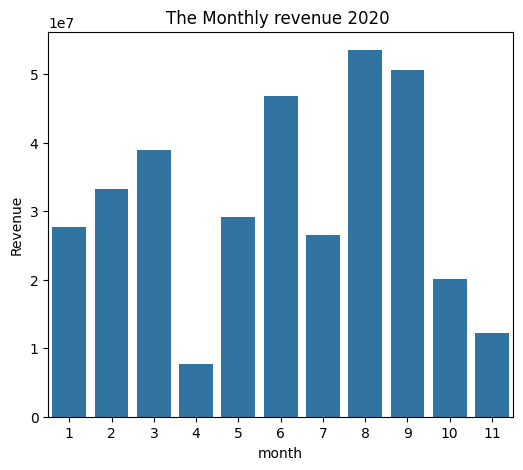

In [23]:
# Group the data by month
# and count the month's revenue
month_rev=(
    df_1.groupby(by='month')['price'] # group by month
    .sum()   # count the revenue
    .reset_index(name='revenue') # create the revenue column
    .sort_values('month') # sort the data by month
)

# prepare the data
category=month_rev['month']
value=month_rev['revenue']

# label 
xlabel='month'
ylabel='Revenue'
title= 'The Monthly revenue 2020 '

# display the graph
Barchart(
    categories=category,
    values=value,
    xlabel=xlabel,
    ylabel=ylabel,
    title=title
)

The bar chart illustrates the distribution of revenue across the months of 2020. August recorded the highest revenue, followed by September and June, indicating strong late-summer sales performance. In contrast, April had the lowest revenue during the observed period, suggesting a significant dip during that month.

3. What are the best-selling and least-selling products?

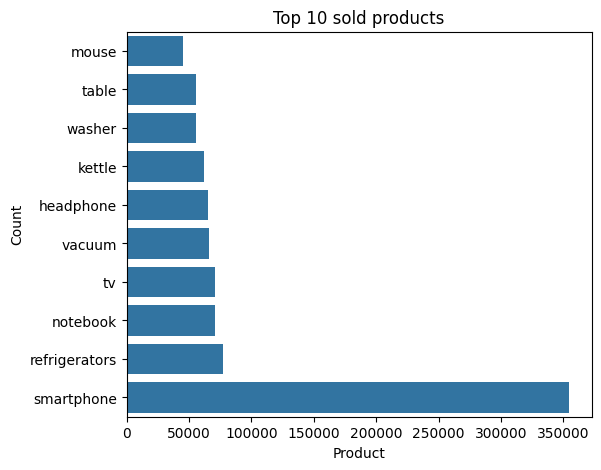

In [24]:
# exclude the data with unkown values in product column
df_prod=df_1[df_1['cat3']!='Unknown']

# group the data by products
# and count the number of records corresponding to each product
product_cnt=(
    df_prod.groupby('cat3')
    .size()
    .reset_index(name='count')
    .sort_values('count')
)

# Top 10 sold products 
top_10=product_cnt.tail(10)

# prepare data
x=top_10['cat3']
y=top_10['count']

# labels 
xlabel='Product'
ylabel='Count'
title='Top 10 sold products'

# display the graph
Barchart(
    categories=x,
    values=y,
    xlabel=xlabel,
    ylabel=ylabel,
    title=title,
    orient='h'
)

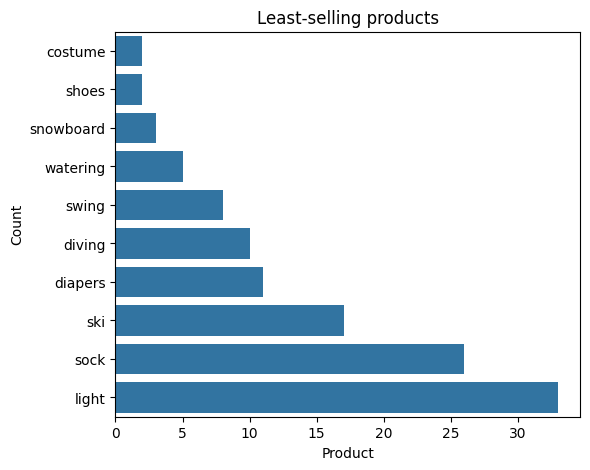

In [25]:
# Top 10 sold products 
Least_10=product_cnt.head(10)

# prepare data
x=Least_10['cat3']
y=Least_10['count']

# labels 
xlabel='Product'
ylabel='Count'
title='Least-selling products'

# display the graph
Barchart(
    categories=x,
    values=y,
    xlabel=xlabel,
    ylabel=ylabel,
    title=title,
    orient='h'
)

The bar charts show the best-selling and least-selling products. Smartphones are the top-selling product with 354,747 units sold, followed by refrigerators, notebooks, and TVs, but with much lower sales numbers.

On the other hand, products such as costumes, shoes, and snowboards are among the least-selling items.

Overall, the results indicate that electronic products, especially smartphones, are the most in-demand items, while non-electronic products have significantly lower sales.

4- What is the distribution of revenue across the porducts

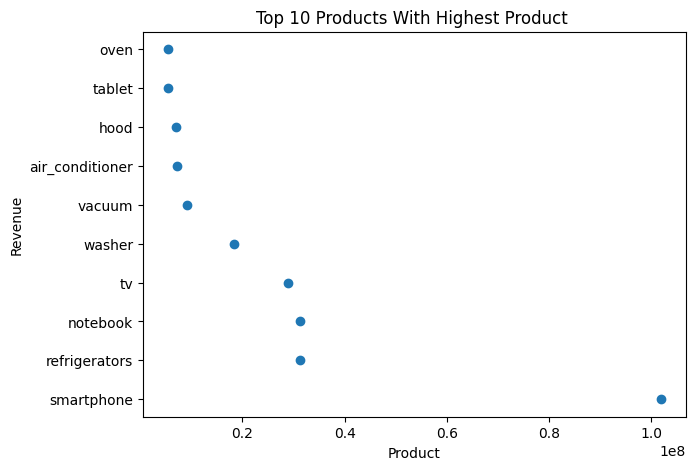

In [27]:
# group the data by products
# count the revenue of each product
product_rev=(
    df_prod.groupby('cat3')['price']
    .sum()
    .reset_index(name='revenue')
    .sort_values('revenue',ascending=False)
)

# Select top 10 products with high revenue
top10_rev=product_rev.head(10)

# display the Dotchart
Dotplot(
    y_data=top10_rev['cat3'],
    x_data=top10_rev['revenue'],
    xlabel='Product',
    ylabel='Revenue',
    title='Top 10 Products With Highest Revenue '
)


The dot plot shows that smartphones generated the highest revenue in 2020, followed by refrigerators, notebooks, and TVs with lower revenue. This suggests that electronic products were the main revenue drivers in 2020.

5. What are the best categories ?

Text(0.5, 1.0, 'Best Categories')

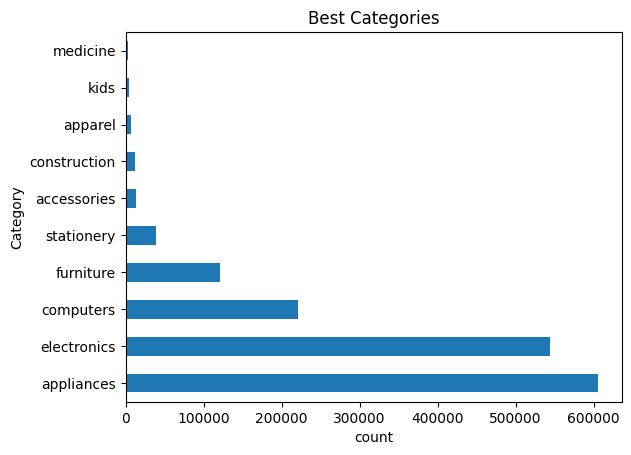

In [35]:
# Exclude Unknown categories
df_cat=df_1[df_1['cat1']!='Unknown']

# Select The best category
top_cat=(
    df_cat['cat1']
    .value_counts(ascending=False)
    .head(10)
    )

# display the bar plot
plt.figure()
top_cat.plot(kind='barh')
plt.xscale('linear')
plt.xlabel('count')
plt.ylabel('Category')
plt.title('Best Categories')

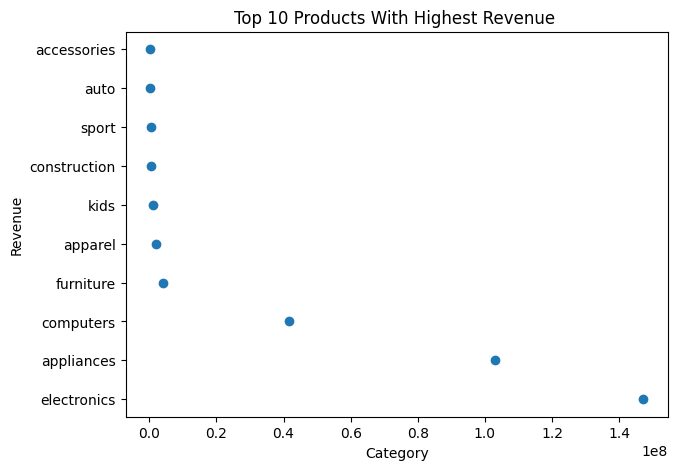

In [37]:
# group the data by category
# count the revenue of each product
product_rev=(
    df_cat.groupby('cat1')['price']
    .sum()
    .reset_index(name='revenue')
    .sort_values('revenue',ascending=False)
)

# Select top 10 category with high revenue
top10_rev=product_rev.head(10)

Dotplot(
    y_data=top10_rev['cat1'],
    x_data=top10_rev['revenue'],
    xlabel='Revenue',
    ylabel='Category',
    title='Top 10 Products With Highest Revenue '
)

6- What are the best brands, and which ones generate the highest revenues? 

Text(0.5, 0, 'revenue')

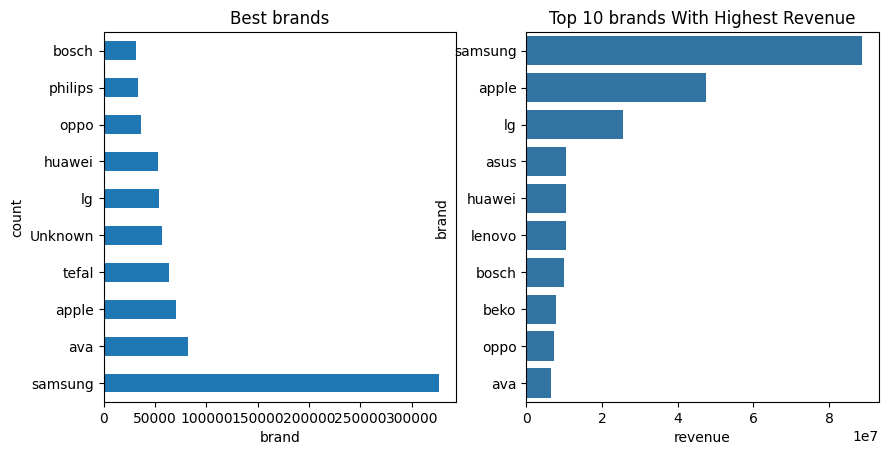

In [42]:
# Exclude Unknown brands
df_brand=df_1[df_1['brand']!='Unknown']

# Select The best brand
top_cat=(
    df_cat['brand']
    .value_counts(ascending=False)
    .head(10)
    )

# Select brands with highest revenue
brand_rev=(
    df_cat.groupby('brand')['price'] # group the data by category
    .sum()                          # count the revenue of each product
    .reset_index(name='revenue')
    .sort_values('revenue',ascending=False)
).head(10)

# Display the Charts
 # Set the figure

fig,axes=plt.subplots(1,2)  
fig.set_figwidth(10)
 # Set the first subplot
top_cat.plot(kind='barh',ax=axes[0])
axes[0].set_title('Best brands')
axes[0].set_xlabel('brand')
axes[0].set_ylabel('count')

# set the second sublot
sns.barplot(data=brand_rev,y='brand',x='revenue',orient='h',ax=axes[1])
axes[1].set_title('Top 10 brands With Highest Revenue')
axes[1].set_ylabel('brand')
axes[1].set_xlabel('revenue')




The charts show that Samsung leads in both sales (326K) and revenue ($88M). AVA ranks second in sales but at a much lower level. Apple generates the second-highest revenue ($47M). This suggests that Samsung is the dominant brand in the market.

7. What is Average Order Value (AOV)?

/home/abdelhakmor5/e-commerce_purchase-history_eda/venv/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7168: RuntimeWarning: invalid value encountered in multiply
  boffset = -0.5 * dr * totwidth * (1 - 1 / nx)


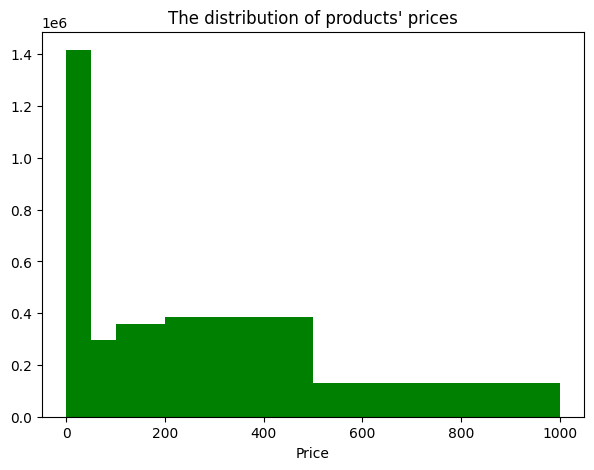

In [57]:
# display the histogram
Histogram(
    data=df_1['price'],
    xlabel='Price',
    title="The distribution of products' prices" ,
    bin=[0, 50, 100, 200, 500, 1000, float('inf')]
)

In [51]:
# Average Product Price
app=df_1['price'].mean()
# total revenue / number of unique orders
aov=df_1['price'].sum() / df_1['order_id'].nunique()

# display the AOV and Average Product Price
print('AOV : ${:,.2f}'.format(aov))
print('Average Product Price: ${:,.2f}'.format(app))

AOV : $243.11
Average Product Price: $132.69


The Average Order Value (AOV) is $243.11 and the Average Product Price is $132.69.
This means that customers usually buy about 1 to 2 products in each order (around 1.8 products on average).

This suggests that most customers do not buy many items at once, but the products are not cheap. The revenue mostly comes from the product price rather than buying many products in one order.

### ***`Aggregations`***

In [ ]:
# Create Optimized Aggregated Tables for Looker Studio
# Note: user_id has 77%+ null values, so we focus on order_id metrics instead

# 1. Daily Sales Summary
daily_sales = df_1.groupby(df_1['event_time'].dt.date).agg({
    'order_id': 'nunique',
    'price': ['sum', 'mean', 'count'],
    'product_id': 'nunique'
}).reset_index()
daily_sales.columns = ['date', 'unique_orders', 'revenue', 'avg_price', 'total_events', 'unique_products']
daily_sales['date'] = pd.to_datetime(daily_sales['date'])

# 2. Monthly Sales Summary
monthly_sales = df_1.groupby('month').agg({
    'order_id': 'nunique',
    'price': ['sum', 'mean', 'count'],
    'product_id': 'nunique',
    'year': 'first'
}).reset_index()
monthly_sales.columns = ['month', 'unique_orders', 'revenue', 'avg_price', 'total_events', 'unique_products', 'year']

# 3. Product Performance (Exclude Unknown products)
df_prod_filtered = df_1[df_1['cat3'] != 'Unknown']
product_performance = df_prod_filtered.groupby('cat3').agg({
    'order_id': 'nunique',
    'price': ['sum', 'mean', 'count'],
    'product_id': 'nunique'
}).reset_index()
product_performance.columns = ['product', 'unique_orders', 'revenue', 'avg_price', 'total_events', 'unique_product_ids']
product_performance = product_performance.sort_values('revenue', ascending=False)

# 4. Category Performance (Exclude Unknown categories)
df_cat_filtered = df_1[df_1['cat1'] != 'Unknown']
category_performance = df_cat_filtered.groupby(['cat1', 'cat2']).agg({
    'order_id': 'nunique',
    'price': ['sum', 'mean', 'count'],
    'product_id': 'nunique'
}).reset_index()
category_performance.columns = ['category_level1', 'category_level2', 'unique_orders', 'revenue', 'avg_price', 'total_events', 'unique_products']
category_performance = category_performance.sort_values('revenue', ascending=False)

# 5. Brand Performance (Exclude Unknown brands)
df_brand_filtered = df_1[df_1['brand'] != 'Unknown']
brand_performance = df_brand_filtered.groupby('brand').agg({
    'order_id': 'nunique',
    'price': ['sum', 'mean', 'count'],
    'product_id': 'nunique'
}).reset_index()
brand_performance.columns = ['brand', 'unique_orders', 'revenue', 'avg_price', 'total_events', 'unique_products']
brand_performance = brand_performance.sort_values('revenue', ascending=False)



### ***`Save Tables for Looker Studio`***

In [ ]:
# Export tables as CSV files for Looker Studio
output_dir = 'looker_studio_data'
os.makedirs(output_dir, exist_ok=True)

# Save all aggregated tables
daily_sales.to_csv(f'{output_dir}/01_daily_sales.csv', index=False)
monthly_sales.to_csv(f'{output_dir}/02_monthly_sales.csv', index=False)
product_performance.to_csv(f'{output_dir}/03_product_performance.csv', index=False)
category_performance.to_csv(f'{output_dir}/04_category_performance.csv', index=False)
brand_performance.to_csv(f'{output_dir}/05_brand_performance.csv', index=False)
price_distribution.to_csv(f'{output_dir}/06_price_distribution.csv', index=False)


print("✓ All CSV files saved successfully in 'looker_studio_data' folder!\n")
